# *Credit Card Default Prediction*

Credit Card Default Prediction using Logistic Regression

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [148]:
df=pd.read_csv(r"C:\Users\gaura\Documents\default of credit card clients.csv")  # Here i loaded the dataset 

# Data Understanding

In [149]:
df.head() # here i checked first 5 recornd for the data understanding

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [150]:
print('shape :',df.shape)   # here i checked the shape,size and column
print('size :',df.size)
print(df.columns)

shape : (30000, 25)
size : 750000
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [151]:
df.info()  # here i checked the datatype and nullcount also column name

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [152]:
df.describe() # here i checked statistical summary such as count,mean,max,std,quartiles

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# Data Cleaning

In [153]:
df.isnull().sum() # here i cheked null values in each column

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [154]:
df.duplicated().sum() # here i checked the duplicate records in a data

np.int64(0)

In [155]:
df=df.drop('ID',axis=1) # here i deleated the id column which is is not important for this task

In [156]:
df.head() # after deleating the column again i cheked , is the column is deleted or not 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [157]:
# Checking outliers
num_col=df.select_dtypes(include='number')

Q1=num_col.quantile(0.25)
Q3=num_col.quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR               # here i checked the outliers with the hep of IQR like how many outliers present in the data
upper=Q3+1.5*IQR               # Outliers can affect model performance, but in my dataset most outliers are valid values, so i did not remove them.

outliers=((lower>num_col) | (upper<num_col)).sum()
outliers

LIMIT_BAL                      167
SEX                              0
EDUCATION                      454
MARRIAGE                         0
AGE                            272
PAY_0                         3130
PAY_2                         4410
PAY_3                         4209
PAY_4                         3508
PAY_5                         2968
PAY_6                         3079
BILL_AMT1                     2400
BILL_AMT2                     2395
BILL_AMT3                     2469
BILL_AMT4                     2622
BILL_AMT5                     2725
BILL_AMT6                     2693
PAY_AMT1                      2745
PAY_AMT2                      2714
PAY_AMT3                      2598
PAY_AMT4                      2994
PAY_AMT5                      2945
PAY_AMT6                      2958
default payment next month    6636
dtype: int64

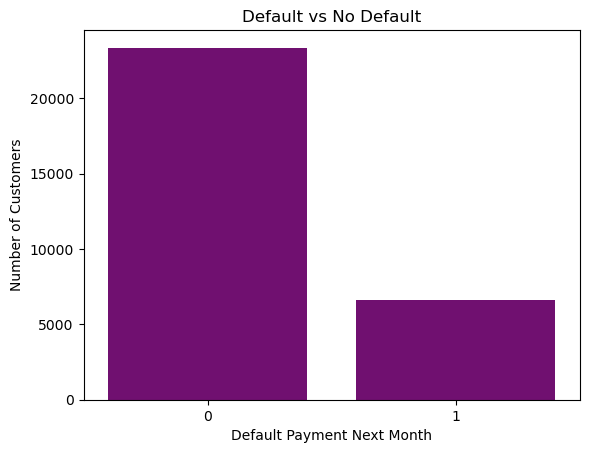

In [158]:
# Default vs No Default — Bar Chart

sns.countplot(x='default payment next month',data=df,color='purple')
plt.title('Default vs No Default')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Number of Customers')
plt.show()                                        #Default: Customer failed to pay as require'   #No Default: Customer paid as required


In this chart, we can see that most customers did not default, while fewer customers defaulted.

# Independent and Dependent 

In [159]:
x = df.drop(['default payment next month'], axis=1)
y = df['default payment next month']             # here i created the data for x=independent and y=dependent 

# Train_Test_split

In [160]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42) # here i splited the data in 4 part

In [44]:
x_train.shape # here i checked the shape of X-train data

(22500, 23)

In [45]:
x_test.shape # here i checked the shape of X-test data

(7500, 23)

# Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)   # here i scaled the the data x_train and x-test
x_test_scaled=scaler.transform(x_test)

print(x_train_scaled.shape)
print(x_test_scaled.shape)

(22500, 23)
(7500, 23)


# Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()                  
model.fit(x_train_scaled,y_train)  

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
y_pred=model.predict(x_test_scaled)
y_pred.shape   # here i made the prediction of 

(7500,)

# Confusion Matrix

In [59]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [60]:
score=accuracy_score(y_test,y_pred)
score # here i cheched the accuracy_score 

0.8088

In [62]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))   # here i checked classification report and confusion matrics

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0.79      0.81      0.77      7500

[[5688  185]
 [1249  378]]


# 5-Fold Cross-Validation

In [67]:
from sklearn.model_selection import cross_val_score

model=LogisticRegression()

cv_score=cross_val_score(          # here i checked the cross validation of logistic regression
    model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
cv_score

array([0.80955556, 0.81266667, 0.812     , 0.81311111, 0.80777778])

# GridSearchCV

In [91]:
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
solver=['newton-cg','lbfgs','liblinear','sag','saga']
max_iter=[100,150,200,250]
c_value=[100,10,1.0,0.1,0.01]

In [92]:
parameter=dict(penalty=penalty,solver=solver,max_iter=max_iter,C=c_value)

In [93]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [94]:
# GridSearchCV:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=model,param_grid=parameter,cv=cv,n_jobs=-1)
grid.fit(x_train_scaled,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'max_iter': [100, 150, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [95]:
grid.best_params_

{'C': 100, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}

In [96]:
grid.best_score_

np.float64(0.811288888888889)

In [104]:
y_pred_grid=grid.predict(x_test_scaled)   # here i predictd the gridsearchcv
y_pred_grid.shape

(7500,)

In [105]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [106]:
score=accuracy_score(y_test,y_pred_grid)   # here i checked the accuracy score of gridsearchCV
score

0.8090666666666667

In [109]:
print(classification_report(y_test,y_pred_grid))  
print()                                             # here i checked the classification reports and confusion matrix of gridsearchCV
print(confusion_matrix(y_test,y_pred_grid))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0.79      0.81      0.77      7500



[[5688  185]
 [1247  380]]


# Randomized Search CV

In [112]:
from sklearn.model_selection import RandomizedSearchCV

In [115]:
model=LogisticRegression()
rs=RandomizedSearchCV(estimator=model,param_distributions=parameter,cv=5,scoring='accuracy')
rs.fit(x_train_scaled,y_train)

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'max_iter': [100, 150, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [116]:
rs.best_params_

{'solver': 'saga', 'penalty': 'l2', 'max_iter': 200, 'C': 1.0}

In [117]:
rs.best_score_

np.float64(0.8111555555555554)

In [120]:
y_pred_rs=rs.predict(x_test_scaled)
y_pred_rs.shape       # here i predicted the randomizedsearchcv 

(7500,)

In [123]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [125]:
score_rs=accuracy_score(y_test,y_pred_rs)
score_rs  # here i checked the accuracy score of randomizedsearchcv

0.8090666666666667

In [128]:
print(confusion_matrix(y_test,y_pred_rs))
print( )                                          # here i checked the classification matrix and classification reports of randomizedsearchcv
print(classification_report(y_test,y_pred_rs))

[[5689  184]
 [1248  379]]

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0.79      0.81      0.77      7500



# Compare Models

In [131]:
print('Logistic Regression:',accuracy_score(y_test,y_pred))
print('GridSearchCV:',accuracy_score(y_test,y_pred_grid))
print('RandomizedSearchCV:', accuracy_score(y_test,y_pred_rs))

Logistic Regression: 0.8090666666666667
GridSearchCV: 0.8090666666666667
RandomizedSearchCV: 0.8090666666666667


In [136]:
print("Logistic Regression")
print(classification_report(y_test, y_pred))
print()
print("GridSearchCV")
print(classification_report(y_test, y_pred_grid))    # here i compaired the models of logistic Regression, gridsearchcv and randomizedsearchcv
print()
print("RandomizedSearchCV")
print(classification_report(y_test, y_pred_rs))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0.79      0.81      0.77      7500


GridSearchCV
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0.79      0.81      0.77      7500


RandomizedSearchCV
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5873
           1       0.67      0.23      0.35      1627

    accuracy                           0.81      7500
   macro avg       0.75      0.60      0.62      7500
weighted avg       0

# Conclusion

Our Logistic Regression model gives 80.91% accuracy. GridSearchCV and RandomizedSearchCV also give the same result.

In this task, i cleaned and prepared the credit card customers data and built logistic regression model to predict the custmer default . The model achieved [80.91% ] accuracy. GridSearchCV and RandomSearchCV also gave the same accuracy/ result, So we can select Logistic Regression as our final model.